# Bloc 5 — Industrialisation du modèle FEM Surrogate

**RNCP 3426 — Compétences couvertes**
- C5.1 : Traçabilité des expériences avec **MLflow** (tracking, registre de modèles)
- C5.2 : Conteneurisation avec **Docker Compose** (API + Dashboard + MinIO + PostgreSQL + Grafana)
- C5.3 : API REST de prédiction avec **FastAPI** (endpoints `/health`, `/version`, `/predict`)
- C5.4 : Tableau de bord interactif avec **Streamlit** (exploration paramétrique)
- C5.5 : Monitoring **Prometheus / Grafana** + alertes Slack

---

## Architecture de la stack

```
┌─────────────────────────────────────────────────────────────────┐
│                        Docker Compose Stack                     │
│                                                                 │
│  ┌──────────┐    HTTP     ┌──────────────┐    SQL    ┌───────┐  │
│  │Streamlit │────────────►│  FastAPI     │──────────►│  PG   │  │
│  │:8501     │             │  :8000       │           │:5432  │  │
│  └──────────┘             └──────┬───────┘           └───────┘  │
│                                  │ LightGBM                     │
│                                  │ registry                     │
│  ┌──────────┐    scrape  ┌───────▼───────┐  S3/MinIO ┌───────┐  │
│  │ Grafana  │◄──────────│  Prometheus   │──────────►│MinIO  │  │
│  │:3000     │            │  :9090        │           │:9000  │  │
│  └──────────┘            └───────────────┘           └───────┘  │
│                                                                 │
│  ┌──────────────────────────────────────┐                       │
│  │  MLflow Tracking Server  :5000       │                       │
│  │  Artifacts → MinIO (s3://mlflow)     │                       │
│  └──────────────────────────────────────┘                       │
└─────────────────────────────────────────────────────────────────┘
```

---
## 0 — Imports & configuration

In [14]:
import json
import os
import pathlib
import subprocess
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import HTML, display

# URLs
API_URL    = 'http://localhost:8000'
MLFLOW_URL = 'http://localhost:5000'
API_AUTH   = ('admin', 'mdp123')

ROOT = pathlib.Path('.').resolve().parent
print('Répertoire projet :', ROOT)
print('API              :', API_URL)
print('MLflow           :', MLFLOW_URL)

Répertoire projet : C:\Users\Administrateur\Desktop\fem-surrogate
API              : http://localhost:8000
MLflow           : http://localhost:5000


---
## C5.1 — MLflow : traçabilité des expériences

MLflow assure la **reproductibilité** et la **gouvernance** du cycle de vie ML :
- **Tracking** : chaque entraînement est loggé (hyperparamètres, métriques, artefacts)
- **Model Registry** : versions, transitions de stage (Staging → Production)
- **Artifacts** : stockés dans MinIO via le protocole S3

> Démarrer la stack si nécessaire : `docker compose up -d mlflow`

In [15]:
# Vérification MLflow
def mlflow_ok() -> bool:
    try:
        r = requests.get(f'{MLFLOW_URL}/health', timeout=3)
        return r.status_code == 200
    except Exception:
        return False

if mlflow_ok():
    print('MLflow : OK')
else:
    print('MLflow non accessible — les cellules MLflow nécessitent : docker compose up -d mlflow')

MLflow : OK


In [16]:
# Lister les expériences via l'API REST MLflow
if mlflow_ok():
    resp = requests.get(f'{MLFLOW_URL}/api/2.0/mlflow/experiments/search',
                        params={'max_results': 20}, timeout=5)
    experiments = resp.json().get('experiments', [])

    rows = []
    for e in experiments:
        rows.append({
            'experiment_id': e['experiment_id'],
            'name':          e['name'],
            'artifact_root': e.get('artifact_location', ''),
            'lifecycle':     e.get('lifecycle_stage', ''),
        })

    df_exp = pd.DataFrame(rows)
    print(f'{len(df_exp)} expérience(s) MLflow trouvée(s) :')
    display(df_exp)
else:
    print('[SKIP] MLflow non accessible')

2 expérience(s) MLflow trouvée(s) :


,experiment_id,name,artifact_root,lifecycle
0,1,fem-surrogate,s3://ml-artifacts/1,active
1,0,Default,s3://ml-artifacts/0,active


In [17]:
# Lister les runs de l'expérience principale
EXP_NAME = 'fem-surrogate'

if mlflow_ok():
    # Trouver l'ID de l'expérience
    resp = requests.get(
        f'{MLFLOW_URL}/api/2.0/mlflow/experiments/get-by-name',
        params={'experiment_name': EXP_NAME}, timeout=5
    )
    if resp.status_code == 200:
        exp_id = resp.json()['experiment']['experiment_id']

        # Chercher les runs
        resp2 = requests.post(
            f'{MLFLOW_URL}/api/2.0/mlflow/runs/search',
            json={'experiment_ids': [exp_id], 'max_results': 20},
            timeout=5
        )
        runs = resp2.json().get('runs', [])

        run_rows = []
        for run in runs:
            info    = run.get('info', {})
            metrics = {m['key']: m['value'] for m in run.get('data', {}).get('metrics', [])}
            params  = {p['key']: p['value'] for p in run.get('data', {}).get('params', [])}
            run_rows.append({
                'run_id':            info.get('run_id', '')[:8],
                'status':            info.get('status', ''),
                'start_time':        pd.to_datetime(info.get('start_time', 0), unit='ms'),
                'r2_displacement':   metrics.get('max.displacement.m_test_r2_orig', float('nan')),
                'r2_von_mises':      metrics.get('max.von.mises.pa_test_r2_orig',  float('nan')),
                'rmse_displacement': metrics.get('max.displacement.m_test_rmse_orig', float('nan')),
                'n_trials':          params.get('n_trials', '?'),
            })

        df_runs = pd.DataFrame(run_rows).sort_values('start_time', ascending=False)
        print(f'{len(df_runs)} run(s) dans "{EXP_NAME}" :')
        display(df_runs.head(10))
    else:
        print(f'Expérience "{EXP_NAME}" introuvable. Lancez d\'abord : python -m src.cli train')
else:
    print('[SKIP] MLflow non accessible')

7 run(s) dans "fem-surrogate" :


,run_id,status,start_time,r2_displacement,r2_von_mises,rmse_displacement,n_trials
0,807bbeb9,FINISHED,2026-05-29 06:35:46.241,NaN,NaN,NaN,?
1,b9253d39,FINISHED,2026-05-28 18:19:07.074,0.980333,0.871220,0.000012,60
2,11f8c9af,FINISHED,2026-05-28 17:47:59.818,0.980333,0.871220,NaN,60
3,5ac299cb,FINISHED,2026-05-28 15:01:09.562,NaN,NaN,NaN,?
4,56091ba9,FINISHED,2026-05-28 14:57:57.546,NaN,NaN,NaN,?
5,bb19fdce,FINISHED,2026-05-26 14:43:07.882,0.966108,0.865894,0.000016,60
6,b6f6fde0,FINISHED,2026-05-26 14:03:17.962,0.966108,0.865894,0.000016,60


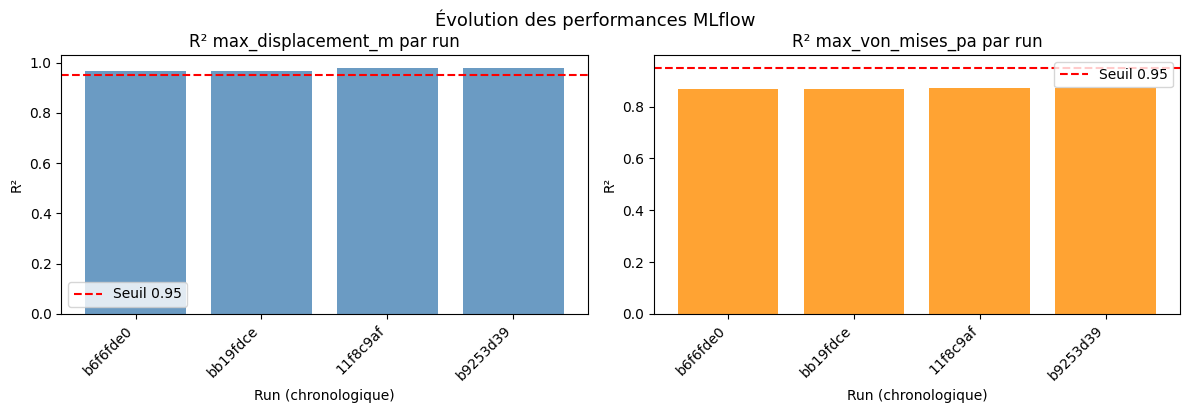

Figure sauvegardée : artifacts/bloc5_mlflow_runs.png


In [18]:
# Visualiser l'évolution des métriques par run
if mlflow_ok() and 'df_runs' in dir() and len(df_runs) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    df_plot = df_runs.dropna(subset=['r2_displacement', 'r2_von_mises']).sort_values('start_time')
    x = range(len(df_plot))

    axes[0].bar(x, df_plot['r2_displacement'], color='steelblue', alpha=0.8)
    axes[0].axhline(0.95, color='red', linestyle='--', label='Seuil 0.95')
    axes[0].set_title('R² max_displacement_m par run')
    axes[0].set_xlabel('Run (chronologique)')
    axes[0].set_ylabel('R²')
    axes[0].legend()
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(df_plot['run_id'].tolist(), rotation=45, ha='right')

    axes[1].bar(x, df_plot['r2_von_mises'], color='darkorange', alpha=0.8)
    axes[1].axhline(0.95, color='red', linestyle='--', label='Seuil 0.95')
    axes[1].set_title('R² max_von_mises_pa par run')
    axes[1].set_xlabel('Run (chronologique)')
    axes[1].set_ylabel('R²')
    axes[1].legend()
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(df_plot['run_id'].tolist(), rotation=45, ha='right')

    plt.tight_layout()
    plt.suptitle('Évolution des performances MLflow', fontsize=13, y=1.02)
    plt.savefig(ROOT / 'artifacts' / 'bloc5_mlflow_runs.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Figure sauvegardée : artifacts/bloc5_mlflow_runs.png')
else:
    print('[SKIP] Données MLflow insuffisantes pour le graphique')

In [19]:
# Démonstration MLflow Python SDK : log d'un run de test
import mlflow

if mlflow_ok():
    mlflow.set_tracking_uri(MLFLOW_URL)
    mlflow.set_experiment('fem-surrogate')

    with mlflow.start_run(run_name='demo_notebook_bloc5') as run:
        # Log de paramètres fictifs
        mlflow.log_params({
            'notebook':       'industria_bloc5',
            'demo_mode':      True,
            'random_state':   42,
        })

        # Log de métriques simulées
        for step, r2 in enumerate([0.92, 0.95, 0.97, 0.98]):
            mlflow.log_metric('r2_demo', r2, step=step)

        run_id = run.info.run_id
        print(f'Run loggé avec succès')
        print(f'Run ID   : {run_id}')
        print(f'UI       : {MLFLOW_URL}/#/experiments/{run.info.experiment_id}/runs/{run_id}')
else:
    print('[SKIP] MLflow non accessible')

Run loggé avec succès
Run ID   : a9db105f38544282855a27fbd9b335fb
UI       : http://localhost:5000/#/experiments/1/runs/a9db105f38544282855a27fbd9b335fb
🏃 View run demo_notebook_bloc5 at: http://localhost:5000/#/experiments/1/runs/a9db105f38544282855a27fbd9b335fb
🧪 View experiment at: http://localhost:5000/#/experiments/1


---
## C5.2 — Docker Compose : infrastructure conteneurisée

La stack complète est définie dans `docker-compose.yml`. Chaque service a une responsabilité unique :

| Service       | Image                  | Port  | Rôle                              |
|---------------|------------------------|-------|-----------------------------------|
| `api`         | `fem-surrogate-api`    | 8000  | FastAPI — prédictions             |
| `dashboard`   | `fem-surrogate-dash`   | 8501  | Streamlit — exploration           |
| `mlflow`      | `fem-surrogate-mlflow` | 5000  | Tracking + Model Registry         |
| `minio`       | `minio/minio`          | 9000  | Stockage S3 (artefacts MLflow)    |
| `db`          | `postgres:15`          | 5432  | Base de données MLflow            |
| `prometheus`  | `prom/prometheus`      | 9090  | Scraping métriques API            |
| `grafana`     | `grafana/grafana`      | 3000  | Tableaux de bord + alertes Slack  |

In [20]:
# État de la stack Docker
result = subprocess.run(
    ['docker', 'compose', 'ps', '--format', 'json'],
    capture_output=True, text=True, cwd=str(ROOT)
)

if result.returncode == 0 and result.stdout.strip():
    lines = [l for l in result.stdout.strip().split('\n') if l.strip()]
    containers = []
    for line in lines:
        try:
            obj = json.loads(line)
            containers.append({
                'Service':  obj.get('Service', obj.get('Name', '?')),
                'Status':   obj.get('Status', '?'),
                'Ports':    obj.get('Publishers', [{}])[0].get('PublishedPort', '') if obj.get('Publishers') else '—',
            })
        except Exception:
            pass

    if containers:
        df_docker = pd.DataFrame(containers)
        print('Conteneurs Docker Compose :')
        display(df_docker)
    else:
        print('Aucun conteneur en cours — lancez : docker compose up -d')
else:
    print('Docker non accessible ou stack arrêtée.')
    print('Démarrer la stack : docker compose up -d')

Conteneurs Docker Compose :


,Service,Status,Ports
0,api,Up 3 minutes (healthy),8000
1,dashboard,Up 3 minutes,8501
2,grafana,Up 3 minutes,3000
3,minio,Up 3 minutes (healthy),9000
4,mlflow,Up 3 minutes (healthy),5000
5,postgres,Up 3 minutes (healthy),0
6,prometheus,Up 3 minutes,9090


In [21]:
# Commandes clés Docker pour référence
docker_commands = {
    'Démarrer la stack':                  'docker compose up -d',
    'Arrêter (garder les données)':        'docker compose down',
    'Arrêter + supprimer volumes':         'docker compose down -v',
    'Voir les logs API':                   'docker compose logs -f api',
    'Reconstruire une image':              'docker compose build api',
    'Redémarrer le dashboard':             'docker compose restart dashboard',
    'Status de tous les services':         'docker compose ps',
    'Utilisation ressources (live)':       'docker stats',
}

print('Commandes Docker Compose utiles :')
print('=' * 55)
for desc, cmd in docker_commands.items():
    print(f'  {desc:<38}  →  {cmd}')

Commandes Docker Compose utiles :
  Démarrer la stack                       →  docker compose up -d
  Arrêter (garder les données)            →  docker compose down
  Arrêter + supprimer volumes             →  docker compose down -v
  Voir les logs API                       →  docker compose logs -f api
  Reconstruire une image                  →  docker compose build api
  Redémarrer le dashboard                 →  docker compose restart dashboard
  Status de tous les services             →  docker compose ps
  Utilisation ressources (live)           →  docker stats


In [22]:
# Persistance des données (bind mounts)
bind_mounts = {
    'MinIO (artefacts S3)':   ROOT / 'data' / 'minio-storage',
    'PostgreSQL (MLflow DB)': ROOT / 'data' / 'postgres',
    'Modèles entraînés':      ROOT / 'artifacts' / 'models',
}

print('Répertoires de persistance (bind mounts) :')
print(f'{"Rôle":<30}  {"Chemin":<45}  {"Existe ?"}')
print('-' * 85)
for role, path in bind_mounts.items():
    exists = 'OUI' if path.exists() else 'NON'
    print(f'{role:<30}  {str(path.relative_to(ROOT)):<45}  {exists}')

Répertoires de persistance (bind mounts) :
Rôle                            Chemin                                         Existe ?
-------------------------------------------------------------------------------------
MinIO (artefacts S3)            data\minio-storage                             OUI
PostgreSQL (MLflow DB)          data\postgres                                  OUI
Modèles entraînés               artifacts\models                               OUI


---
## C5.3 — FastAPI : API REST de prédiction

La **FastAPI** expose 4 endpoints :

| Méthode | Endpoint   | Auth         | Description                        |
|---------|------------|--------------|------------------------------------|
| GET     | `/health`  | Non          | Sonde disponibilité + état modèle  |
| GET     | `/version` | Basic Auth   | Version API + modèle + nb features |
| POST    | `/predict` | Basic Auth   | Inférence surrogate (1 cas)        |
| GET     | `/metrics` | Non          | Métriques Prometheus               |

> Démarrer l'API localement : `uvicorn src.api.main:app --reload --port 8000`  
> Ou via Docker : `docker compose up -d api`

In [23]:
# GET /health
def api_ok() -> bool:
    try:
        r = requests.get(f'{API_URL}/health', timeout=3)
        return r.status_code == 200
    except Exception:
        return False

if api_ok():
    resp = requests.get(f'{API_URL}/health', timeout=5)
    health = resp.json()
    print('GET /health')
    print(json.dumps(health, indent=2))

    status_color = 'green' if health.get('status') == 'ok' else 'orange'
    display(HTML(
        f'<span style="color:{status_color}; font-weight:bold;">'
        f'Statut : {health.get("status", "?").upper()}</span> — '
        f'Modèle chargé : {health.get("model_loaded", False)} — '
        f'Version : {health.get("model_version", "inconnue")}'
    ))
else:
    print('API non accessible — démarrer avec : docker compose up -d api')
    print('Ou en local : uvicorn src.api.main:app --reload --port 8000')

GET /health
{
  "status": "ok",
  "model_loaded": true,
  "model_version": "v20260528_181908"
}


In [24]:
# GET /version
if api_ok():
    resp = requests.get(f'{API_URL}/version', auth=API_AUTH, timeout=5)
    version_info = resp.json()
    print('GET /version')
    print(json.dumps(version_info, indent=2))
else:
    print('[SKIP] API non accessible')

GET /version
{
  "api_version": "1.0.0",
  "model_version": "v20260528_181908",
  "model_name": "lgbm_surrogate",
  "feature_count": 42
}


In [25]:
# POST /predict — Cas 1 : plaque avec trou (acier)
PAYLOAD_HOLE = {
    'geometry_type':    'with_hole',
    'length_m':          0.20,
    'height_m':          0.05,
    'young_modulus_pa':  210_000_000_000,
    'poisson_ratio':     0.30,
    'traction_pa':       50_000_000,
    'material_category': 'steel',
    'dimension_category':'small',
    'hole_radius_ratio': 0.20,
}

if api_ok():
    resp = requests.post(f'{API_URL}/predict', json=PAYLOAD_HOLE, auth=API_AUTH, timeout=10)
    resp.raise_for_status()
    pred1 = resp.json()
    print('POST /predict — plaque avec trou (acier)')
    print(json.dumps(pred1, indent=2))
    disp = pred1['predictions']['max_displacement_m']
    vm   = pred1['predictions']['max_von_mises_pa']
    print(f'\nMax déplacement : {disp:.4e} m  ({disp*1e3:.3f} mm)')
    print(f'Max Von Mises   : {vm:.4e} Pa  ({vm/1e6:.2f} MPa)')
else:
    print('[SKIP] API non accessible')
    pred1 = None

POST /predict — plaque avec trou (acier)
{
  "model_version": "v20260528_181908",
  "predictions": {
    "max_displacement_m": 5.01642805250712e-05,
    "max_von_mises_pa": 159492114.41478583
  },
  "input_summary": {
    "geometry_type": "with_hole",
    "length_m": 0.2,
    "height_m": 0.05,
    "young_modulus_pa": 210000000000.0,
    "traction_pa": 50000000.0,
    "hole_radius_ratio": 0.2
  }
}

Max déplacement : 5.0164e-05 m  (0.050 mm)
Max Von Mises   : 1.5949e+08 Pa  (159.49 MPa)


In [26]:
# POST /predict — Cas 2 : plaque pleine (aluminium)
PAYLOAD_SOLID = {
    'geometry_type':     'without_hole',
    'length_m':           0.30,
    'height_m':           0.08,
    'young_modulus_pa':   70_000_000_000,
    'poisson_ratio':      0.33,
    'traction_pa':        20_000_000,
    'material_category':  'aluminum',
    'dimension_category': 'medium',
}

# POST /predict — Cas 3 : trou excentré (titane)
PAYLOAD_MOVING = {
    'geometry_type':     'with_hole_moving',
    'length_m':           0.25,
    'height_m':           0.06,
    'young_modulus_pa':   116_000_000_000,
    'poisson_ratio':      0.32,
    'traction_pa':        35_000_000,
    'material_category':  'titanium',
    'dimension_category': 'small',
    'hole_radius_ratio':  0.15,
    'hole_cx_ratio':      0.40,
    'hole_cy_ratio':      0.50,
}

results_batch = []
if api_ok():
    for payload, label in [(PAYLOAD_HOLE, 'with_hole / steel'),
                            (PAYLOAD_SOLID, 'without_hole / aluminum'),
                            (PAYLOAD_MOVING, 'with_hole_moving / titanium')]:
        r = requests.post(f'{API_URL}/predict', json=payload, auth=API_AUTH, timeout=10)
        r.raise_for_status()
        preds = r.json()['predictions']
        results_batch.append({
            'Cas':                  label,
            'Déplacement max (mm)': f"{preds['max_displacement_m']*1e3:.4f}",
            'Von Mises max (MPa)':  f"{preds['max_von_mises_pa']/1e6:.2f}",
        })

    df_batch = pd.DataFrame(results_batch)
    print('Prédictions pour 3 géométries :')
    display(df_batch)
else:
    print('[SKIP] API non accessible')

Prédictions pour 3 géométries :


,Cas,Déplacement max (mm),Von Mises max (MPa)
0,with_hole / steel,0.0502,159.49
1,without_hole / aluminum,0.0814,31.77
2,with_hole_moving / titanium,0.0744,100.80


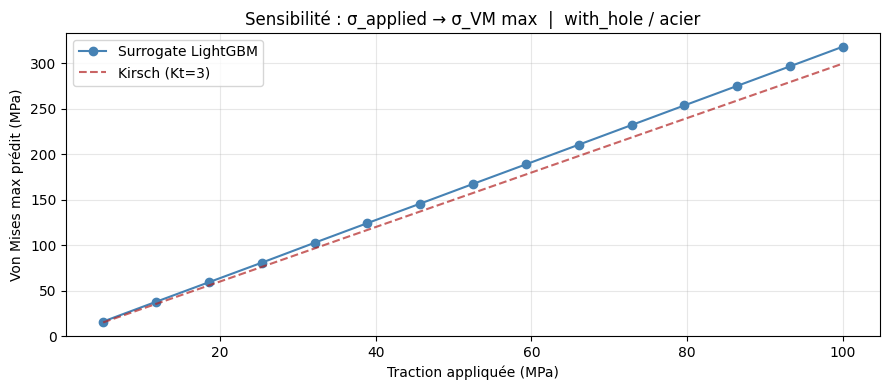

Figure sauvegardée : artifacts/bloc5_sensitivity_api.png


In [27]:
# Analyse de sensibilité via l'API : traction → Von Mises
if api_ok():
    base = dict(PAYLOAD_HOLE)
    tractions_mpa = np.linspace(5, 100, 15)
    vm_predictions = []

    for t_mpa in tractions_mpa:
        p = dict(base)
        p['traction_pa'] = float(t_mpa * 1e6)
        r = requests.post(f'{API_URL}/predict', json=p, auth=API_AUTH, timeout=5)
        vm_predictions.append(r.json()['predictions']['max_von_mises_pa'] / 1e6)

    # Référence analytique (Kirsch : Kt ≈ 3 pour trou centré)
    vm_kirsch = [t * 3.0 for t in tractions_mpa]

    plt.figure(figsize=(9, 4))
    plt.plot(tractions_mpa, vm_predictions, 'o-', color='steelblue', label='Surrogate LightGBM')
    plt.plot(tractions_mpa, vm_kirsch, '--', color='firebrick', alpha=0.7, label='Kirsch (Kt=3)')
    plt.xlabel('Traction appliquée (MPa)')
    plt.ylabel('Von Mises max prédit (MPa)')
    plt.title('Sensibilité : σ_applied → σ_VM max  |  with_hole / acier')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(ROOT / 'artifacts' / 'bloc5_sensitivity_api.png', dpi=120)
    plt.show()
    print('Figure sauvegardée : artifacts/bloc5_sensitivity_api.png')
else:
    print('[SKIP] API non accessible')

Latence sur 30 appels /predict (ms) :
  Médiane  : 26.6 ms
  Moyenne  : 28.8 ms
  P95      : 40.9 ms
  Max      : 49.0 ms


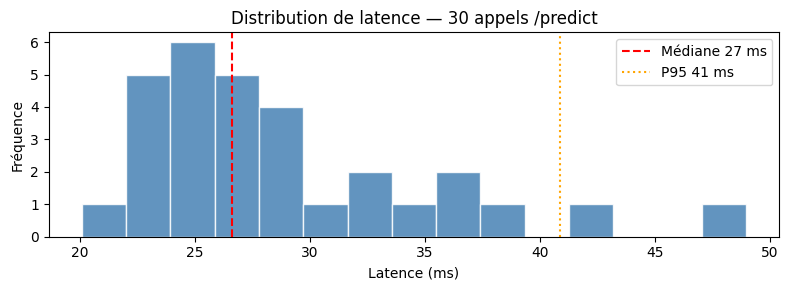

Figure sauvegardée : artifacts/bloc5_latency.png


In [28]:
# Mesure de la latence (N appels)
import time

if api_ok():
    N = 30
    latencies_ms = []
    for _ in range(N):
        t0 = time.perf_counter()
        requests.post(f'{API_URL}/predict', json=PAYLOAD_HOLE, auth=API_AUTH, timeout=5)
        latencies_ms.append((time.perf_counter() - t0) * 1000)

    lat = np.array(latencies_ms)
    print(f'Latence sur {N} appels /predict (ms) :')
    print(f'  Médiane  : {np.median(lat):.1f} ms')
    print(f'  Moyenne  : {np.mean(lat):.1f} ms')
    print(f'  P95      : {np.percentile(lat, 95):.1f} ms')
    print(f'  Max      : {lat.max():.1f} ms')

    plt.figure(figsize=(8, 3))
    plt.hist(lat, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
    plt.axvline(np.median(lat), color='red', linestyle='--', label=f'Médiane {np.median(lat):.0f} ms')
    plt.axvline(np.percentile(lat, 95), color='orange', linestyle=':', label=f'P95 {np.percentile(lat,95):.0f} ms')
    plt.xlabel('Latence (ms)')
    plt.ylabel('Fréquence')
    plt.title(f'Distribution de latence — {N} appels /predict')
    plt.legend()
    plt.tight_layout()
    plt.savefig(ROOT / 'artifacts' / 'bloc5_latency.png', dpi=120)
    plt.show()
    print('Figure sauvegardée : artifacts/bloc5_latency.png')
else:
    print('[SKIP] API non accessible')

In [29]:
# Documentation OpenAPI (Swagger)
if api_ok():
    resp = requests.get(f'{API_URL}/openapi.json', timeout=5)
    schema = resp.json()

    print(f'API titre   : {schema["info"]["title"]}')
    print(f'API version : {schema["info"]["version"]}')
    print(f'\nEndpoints exposés :')
    for path, methods in schema['paths'].items():
        for method, details in methods.items():
            tags = details.get('tags', ['?'])
            print(f'  {method.upper():<6}  {path:<15}  [{tags[0]}]  {details.get("summary", "")}')

    print(f'\nSwagger UI   : {API_URL}/docs')
    print(f'ReDoc        : {API_URL}/redoc')
else:
    print('[SKIP] API non accessible')

API titre   : FEM Surrogate API
API version : 1.0.0

Endpoints exposés :
  GET     /health          [ops]  Health
  GET     /version         [ops]  Version
  POST    /predict         [inference]  Predict
  GET     /metrics         [?]  Metrics

Swagger UI   : http://localhost:8000/docs
ReDoc        : http://localhost:8000/redoc


---
## C5.4 — Streamlit : tableau de bord interactif

Le dashboard `src/dashboard/app.py` offre :
- **Formulaire** : saisie des paramètres géométriques et matériaux
- **Prédiction** : appel de `POST /predict` et affichage des résultats
- **Contexte physique** : estimation analytique (Kirsch, Hooke) vs modèle
- **Analyse de sensibilité** : balayage 1-D sur n'importe quel paramètre

> Démarrer : `streamlit run src/dashboard/app.py`  
> URL : http://localhost:8501

In [30]:
# Vérification accès Streamlit
STREAMLIT_URL = 'http://localhost:8501'

try:
    r = requests.get(STREAMLIT_URL, timeout=3)
    print(f'Streamlit accessible : {STREAMLIT_URL}  (HTTP {r.status_code})')
except Exception:
    print(f'Streamlit non accessible — démarrer avec :')
    print('  docker compose up -d dashboard')
    print('  ou : streamlit run src/dashboard/app.py')

Streamlit accessible : http://localhost:8501  (HTTP 200)


In [31]:
# Extrait du code dashboard (lecture du fichier source)
dash_path = ROOT / 'src' / 'dashboard' / 'app.py'
if dash_path.exists():
    lines = dash_path.read_text(encoding='utf-8').split('\n')
    # Afficher les sections clés (formulaire + prédiction)
    print(f'Source : {dash_path}  ({len(lines)} lignes)')
    print(f'Taille : {dash_path.stat().st_size / 1024:.1f} KB')
    print()

    # Résumé des fonctions
    fns = [l.strip() for l in lines if l.strip().startswith('def ')]
    print('Fonctions :')
    for fn in fns:
        print(' ', fn)
else:
    print('src/dashboard/app.py introuvable')

Source : C:\Users\Administrateur\Desktop\fem-surrogate\src\dashboard\app.py  (354 lignes)
Taille : 12.6 KB

Fonctions :
  def _get_version() -> dict:
  def _get_health() -> dict:
  def _predict(payload: dict) -> dict | None:
  def _analytical_estimate(p: dict) -> tuple[float, float]:


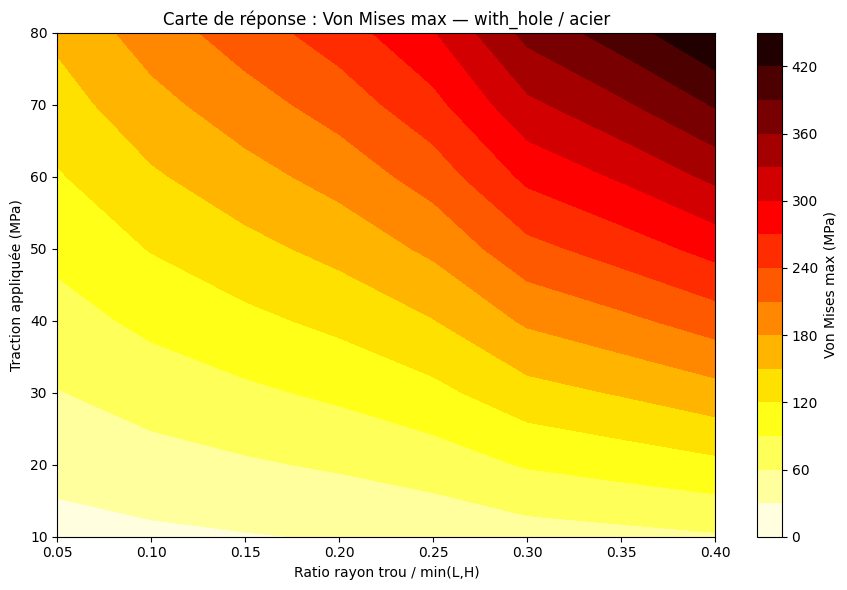

Surface de réponse sauvegardée : artifacts/bloc5_response_surface.png


In [32]:
# Simulation d'un sweep 2-D : traction × hole_radius → Von Mises
# (Reproduit ce que fait le dashboard Streamlit, mais en notebook)

if api_ok():
    tractions_mpa  = np.linspace(10, 80, 8)
    hole_ratios    = np.linspace(0.05, 0.40, 8)
    vm_grid = np.zeros((len(tractions_mpa), len(hole_ratios)))

    base = dict(PAYLOAD_HOLE)
    for i, t in enumerate(tractions_mpa):
        for j, hr in enumerate(hole_ratios):
            p = dict(base)
            p['traction_pa']      = float(t * 1e6)
            p['hole_radius_ratio'] = float(hr)
            r = requests.post(f'{API_URL}/predict', json=p, auth=API_AUTH, timeout=5)
            vm_grid[i, j] = r.json()['predictions']['max_von_mises_pa'] / 1e6

    fig, ax = plt.subplots(figsize=(9, 6))
    c = ax.contourf(hole_ratios, tractions_mpa, vm_grid, levels=15, cmap='hot_r')
    plt.colorbar(c, ax=ax, label='Von Mises max (MPa)')
    ax.set_xlabel('Ratio rayon trou / min(L,H)')
    ax.set_ylabel('Traction appliquée (MPa)')
    ax.set_title('Carte de réponse : Von Mises max — with_hole / acier')
    plt.tight_layout()
    plt.savefig(ROOT / 'artifacts' / 'bloc5_response_surface.png', dpi=120)
    plt.show()
    print('Surface de réponse sauvegardée : artifacts/bloc5_response_surface.png')
else:
    print('[SKIP] API non accessible')

---
## C5.5 — Monitoring Prometheus / Grafana + Alertes Slack

La stack de monitoring collecte et visualise les métriques de l'API en temps réel.

- **Prometheus** scrape `/metrics` (FastAPI) toutes les 15 secondes
- **Grafana** affiche les dashboards : latence P95, taux d'erreurs, requêtes/seconde
- **Alertes** : déclenchées si latence P95 > 500 ms → notification Slack

In [33]:
# Vérification Prometheus
PROMETHEUS_URL = 'http://localhost:9090'

def prom_query(q: str) -> dict:
    try:
        r = requests.get(f'{PROMETHEUS_URL}/api/v1/query',
                         params={'query': q}, timeout=5)
        return r.json() if r.status_code == 200 else {}
    except Exception:
        return {}

health_prom = prom_query('up')
if health_prom.get('status') == 'success':
    results = health_prom['data']['result']
    print(f'Prometheus accessible — {len(results)} cible(s) surveillée(s) :')
    for r in results:
        job = r['metric'].get('job', '?')
        val = r['value'][1]
        print(f'  {job:<20} up={val}')
else:
    print('Prometheus non accessible — démarrer avec : docker compose up -d prometheus')

Prometheus accessible — 4 cible(s) surveillée(s) :
  minio                up=1
  mlflow               up=0
  fem_api              up=1
  prometheus           up=1


In [34]:
# Requêtes Prometheus sur les métriques FastAPI
prom_queries = {
    'Requêtes totales /predict':      'sum(http_requests_total{handler="/predict"})',
    'Latence médiane (s)':            'histogram_quantile(0.50, rate(http_request_duration_seconds_bucket[5m]))',
    'Latence P95 (s)':                'histogram_quantile(0.95, rate(http_request_duration_seconds_bucket[5m]))',
    'Taux erreurs 5xx (%)':           'rate(http_requests_total{status_code=~"5.."}[5m]) * 100',
}

print('Métriques Prometheus :')
print(f'{"Métrique":<40}  {"Valeur"}')
print('-' * 60)
for label, q in prom_queries.items():
    result = prom_query(q)
    if result.get('status') == 'success' and result['data']['result']:
        val = result['data']['result'][0]['value'][1]
        print(f'{label:<40}  {float(val):.4f}')
    else:
        print(f'{label:<40}  (non disponible)')

Métriques Prometheus :
Métrique                                  Valeur
------------------------------------------------------------
Requêtes totales /predict                 (non disponible)
Latence médiane (s)                       nan
Latence P95 (s)                           0.0950
Taux erreurs 5xx (%)                      (non disponible)


In [35]:
# Résumé des URLs de la stack
services = [
    ('FastAPI (Swagger UI)',      f'{API_URL}/docs'),
    ('FastAPI (ReDoc)',           f'{API_URL}/redoc'),
    ('FastAPI /health',          f'{API_URL}/health'),
    ('FastAPI /metrics',         f'{API_URL}/metrics'),
    ('Streamlit Dashboard',      'http://localhost:8501'),
    ('MLflow Tracking UI',       MLFLOW_URL),
    ('MinIO Console',            'http://localhost:9001'),
    ('Prometheus UI',            PROMETHEUS_URL),
    ('Grafana Dashboards',       'http://localhost:3000'),
]

print('=== URLs de la stack industrielle ===')
for name, url in services:
    try:
        r = requests.get(url, timeout=2, allow_redirects=True)
        status = 'OK' if r.status_code < 400 else f'HTTP {r.status_code}'
    except Exception:
        status = 'OFFLINE'
    icon = '' if status == 'OK' else ''
    print(f'{icon}  {name:<30}  {url:<40}  [{status}]')

=== URLs de la stack industrielle ===
  FastAPI (Swagger UI)            http://localhost:8000/docs                [OK]
  FastAPI (ReDoc)                 http://localhost:8000/redoc               [OK]
  FastAPI /health                 http://localhost:8000/health              [OK]
  FastAPI /metrics                http://localhost:8000/metrics             [OK]
  Streamlit Dashboard             http://localhost:8501                     [OK]
  MLflow Tracking UI              http://localhost:5000                     [OK]
  MinIO Console                   http://localhost:9001                     [OK]
  Prometheus UI                   http://localhost:9090                     [OK]
  Grafana Dashboards              http://localhost:3000                     [OK]


---
## Synthèse — Pipeline complet bout-en-bout

```
Données FEM
    │
    ▼  python -m src.cli ingest           (Bloc 1 — HDFS/MinIO)
Lac de données (MinIO S3)
    │
    ▼  python -m src.cli build-features   (Bloc 2 — Feature engineering)
data/processed/{train,val,test}.parquet
    │
    ▼  python -m src.cli train            (Bloc 3 — LightGBM + Optuna)
artifacts/models/<version>/              ← loggé dans MLflow
    │
    ├──► notebooks/dl_bloc4.ipynb        (Bloc 4 — CNN + MobileNetV2)
    │    ├── data/unstructured/images/   (51 550 images Kirsch PNG)
    │
    ▼  docker compose up -d              (Bloc 5 — Industrialisation)
FastAPI :8000  ──►  Streamlit :8501
    │
    ▼  Prometheus :9090  ──►  Grafana :3000  ──►  Slack alerts
```

**Reproductibilité assurée par :**
- `manifest.json` (git hash, versions packages, SHA-256 dataset) dans chaque artefact modèle
- MLflow : tracking complet hyperparamètres, métriques, artefacts
- Docker : images immuables versionnées
- Bind mounts : données persistantes entre redémarrages de containers

In [ ]:
# Vérification finale des artefacts générés dans ce notebook
artifacts_dir = ROOT / 'artifacts'
bloc5_files = sorted(artifacts_dir.glob('bloc5_*.png'))

if bloc5_files:
    print('Artefacts Bloc 5 générés :')
    for f in bloc5_files:
        size_kb = f.stat().st_size / 1024
        print(f'  {f.name:<45}  {size_kb:.1f} KB')
else:
    print('Aucun artefact Bloc 5 — relancer les cellules avec l\'API et MLflow actifs.')

print('\nBloc 5 terminé.')

Artefacts Bloc 5 générés :
  bloc5_latency.png                              22.1 KB
  bloc5_mlflow_runs.png                          40.8 KB
  bloc5_response_surface.png                     48.0 KB
  bloc5_sensitivity_api.png                      53.2 KB

Bloc 5 terminé.


: 